In [1]:
import numpy as np 
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

import math
import pandas as pd 
import matplotlib.pyplot as plt

# import seaborn as sns
import sklearn.metrics as metrics
%matplotlib inline
import os
# from pandas_ml import ConfusionMatrix

In [32]:
df_train = pd.read_csv("./data/df_train.csv",index_col=0)
# df_train2 = df_train.drop(df_train[df_train['attack_type'] == 1].index)
df_train_1 = df_train[df_train['attack_type'].isin([1])]
df_train_0 = df_train[df_train['attack_type'].isin([0])]

df_ma, df_mi = train_test_split(df_train_1, test_size=0.1, random_state=42)
df_train2 = df_train_0.append(df_mi)

X_train, X_test, y_train, y_test = train_test_split(df_train2.drop(['attack_type'],axis=1), df_train2['attack_type'], test_size=0.2, random_state=42)

In [33]:
df_train2.shape

(84201, 41)

In [35]:
Y_train = y_train
Y_test = y_test
dict = {}
for i in Y_train:
    dict.update({i:dict.get(i,0)+1})
dict

{0: 61648, 1: 5712}

In [36]:
from sklearn.ensemble import AdaBoostClassifier
from imblearn.ensemble import EasyEnsembleClassifier

from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import RUSBoostClassifier

In [37]:
accuracy_test22 = np.empty((20))
accuracy_train22 = np.empty((20))

i = 1
while i<=20:
    model22 = EasyEnsembleClassifier(n_estimators=i*2, n_jobs=1,
             replacement=False, sampling_strategy='auto',verbose=0, warm_start=False,
                                     base_estimator=AdaBoostClassifier(n_estimators=10,random_state=42))
    model22.fit(X_train,Y_train)
    final_ans_test = model22.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test22[i-1] = acc
    final_ans_train = model22.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train22[i-1] = acc
    i = i+1
    print(i,end=" ")

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 

In [38]:
accuracy_test3 = np.empty((20))
accuracy_train3 = np.empty((20))

i = 1
while i<=20:
    model3 = BalancedBaggingClassifier(n_estimators=i*2, random_state=42)
    model3.fit(X_train,Y_train)
    final_ans_test = model3.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test3[i-1] = acc
    final_ans_train = model3.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train3[i-1] = acc
    i = i+1

In [39]:
def BalanceCascade(X_train, y_train, X_test, num):
    X_train = X_train.values
    X_test = X_test.values
    y_train = y_train.values
    negnum = y_train[y_train == 0].shape[0]
    posnum = y_train[y_train == 1].shape[0]
    neg_index = np.argwhere(y_train == 0).reshape(negnum, )
    pos_index = np.argwhere(y_train == 1).reshape(posnum, )
    pos_train = X_train[pos_index, :]

    FP = pow(posnum / negnum, 1 / (num - 1))
    classifiers = {};
    thresholds = {};
    test_prob = np.empty((X_test.shape[0], num))
    for i in range(num):
        classifiers[i] = AdaBoostClassifier()
        neg_train_index = np.random.permutation(neg_index)[:posnum]
        neg_train = X_train[neg_train_index, :]
        cur_X_train = np.r_[pos_train, neg_train]
        cur_y_train = np.r_[y_train[pos_index], y_train[neg_train_index]]
        classifiers[i].fit(cur_X_train, cur_y_train)
        predict_result = classifiers[i].predict_proba(X_train[neg_index, :])[:, -1]
        thresholds[i] = np.sort(predict_result)[int(neg_index.shape[0] * (1 - FP))] - 0.5
        neg_index = np.argwhere(predict_result >= (thresholds[i] + 0.5)).reshape(-1, )
        test_prob[:, i] = classifiers[i].predict_proba(X_test)[:, -1] + thresholds[i]
#         print("No.{} Classifier Training Finished".format(i))
    test_prob_result = np.average(test_prob, axis=1)
    test_prob_result = np.around(test_prob_result, decimals=0, out=None)
    test_prob_result = pd.DataFrame(test_prob_result)
    return test_prob_result

accuracy_test6 = np.empty((20))
accuracy_train6 = np.empty((20))
i = 1

while i<=20:
    final_ans_test = BalanceCascade(X_train, y_train, X_test, i+1)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test6[i-1] = acc
    
    final_ans_train = BalanceCascade(X_train, y_train, X_train, i+1)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train6[i-1] = acc
    i = i+1
    print(i,end=" ")

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 

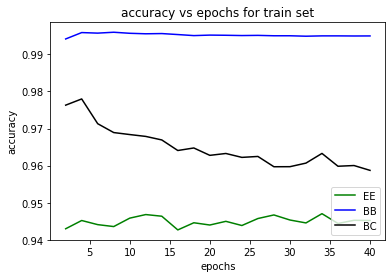

In [40]:
x = np.empty((20))
j = 1
while j<=20:
    x[j-1] = j*2
    j = j+1

# plt.plot(x, accuracy_test, label="adaboost test accuracy")
# plt.plot(x,accuracy_train,label="adaboost train accuracy")
# plt.plot(x, accuracy_test, c= 'red', label = "test", linestyle='-')
# plt.plot(x,accuracy_train, c= 'green', label ="train", linestyle='-')

# plt.plot(x, accuracy_train, c= 'red', label = "AB", linestyle='-')
# plt.plot(x, accuracy_train2, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_train22, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_train3, c= 'blue', label = "BB", linestyle='-')
# plt.plot(x, accuracy_train4, c= 'yellow', label = "BRF", linestyle='-')
# plt.plot(x, accuracy_train5, c= 'black', label = "RUSB", linestyle='-')
plt.plot(x, accuracy_train6, c= 'black', label = "BC", linestyle='-')
# plt.plot(1,acc_test,'yo')
# plt.plot(1,acc_train,'go')
plt.xlabel('epochs')  
plt.ylabel('accuracy') 
  
# giving a title to my graph 
plt.title('accuracy vs epochs for train set') 
plt.legend(loc = 'lower right')
# function to show the plot 
plt.show() 


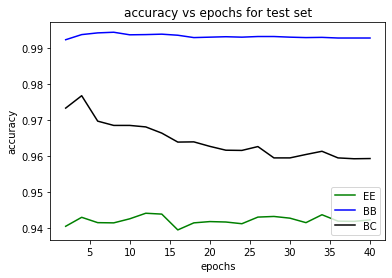

In [41]:
# Task 3

x = np.empty((20))
j = 1
while j<=20:
    x[j-1] = j*2
    j = j+1

# plt.plot(x, accuracy_test, label="adaboost test accuracy")
# plt.plot(x,accuracy_train,label="adaboost train accuracy")
# plt.plot(x, accuracy_test, c= 'red', label = "test", linestyle='-')
# plt.plot(x,accuracy_train, c= 'green', label ="train", linestyle='-')

# plt.plot(x, accuracy_test, c= 'red', label = "AB", linestyle='-')
plt.plot(x, accuracy_test22, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_test3, c= 'blue', label = "BB", linestyle='-')
# plt.plot(x, accuracy_test4, c= 'yellow', label = "BRF", linestyle='-')
# plt.plot(x, accuracy_test5, c= 'black', label = "RUSB", linestyle='-')
plt.plot(x, accuracy_test6, c= 'black', label = "BC", linestyle='-')
# plt.plot(1,acc_test,'yo')
# plt.plot(1,acc_train,'go')
plt.xlabel('epochs')  
plt.ylabel('accuracy') 
  
# giving a title to my graph 
plt.title('accuracy vs epochs for test set') 
plt.legend(loc = 'lower right')
# function to show the plot 
plt.show() 